# **Analyse des dépenses au sein de l'assurance maladie**
## **Objectif :**
- Etudier les fluctuations des dépenses de la caisse primaire des assurances maladie
- Définir les secteurs et raisons des dépenses les plus présents

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**

In [9]:
path = "../../data/silver/depenses_timeseries_features_2015_2025.csv"
path_union = "../../data/silver/depenses_timeseries_features_union_2015_2025.csv"

df = pd.read_csv(path, delimiter=";")
df_union = pd.read_csv(path_union, delimiter=";")

In [10]:
df.head()

,date,Autres,Cures thermales,Dentistes,Généralistes,Indemnités journalières (IJ),Infirmières,Kinésithérapeutes,Laboratoires,Liste des produits et prestations (LPP),...,Orthoptistes,Pédicures,Remboursement de soins à l'étranger,Sages-femmes,Spécialistes,Total,Transports,dont IJ maladie,"dont autres médicaments (franchises, Rosp, gardes pharmacies …)",dont rétrocession hospitalière
0,2015-01-01,2.510100e+06,1.356945e+07,2.183601e+08,7.455998e+08,7.783985e+08,4.173681e+08,2.489425e+08,2.262580e+08,4.094080e+08,...,5.171915e+06,1.385455e+06,1.312802e+07,1.675119e+07,7.813881e+08,6.028024e+09,2.855157e+08,5.540391e+08,7.731469e+07,2.208109e+08
1,2015-02-01,4.016426e+06,1.625153e+07,2.176725e+08,4.615647e+08,7.746956e+08,4.177061e+08,2.474070e+08,2.265094e+08,3.972281e+08,...,4.949724e+06,1.386585e+06,1.306531e+07,1.657797e+07,7.503774e+08,5.561082e+09,2.781105e+08,5.552457e+08,-4.415430e+07,2.236308e+08
2,2015-03-01,5.051655e+06,1.807191e+07,2.341007e+08,4.610908e+08,7.790071e+08,4.205450e+08,2.619559e+08,2.365197e+08,4.251686e+08,...,5.481767e+06,1.505579e+06,1.334480e+07,1.780274e+07,7.793177e+08,5.705020e+09,2.902507e+08,5.549771e+08,-4.332721e+07,2.298866e+08
3,2015-04-01,6.788215e+06,1.768251e+07,2.253043e+08,4.526270e+08,7.773361e+08,4.242497e+08,2.571210e+08,2.392123e+08,4.269860e+08,...,5.260044e+06,1.445524e+06,1.325068e+07,1.769039e+07,7.756445e+08,5.659840e+09,2.875983e+08,5.578931e+08,-4.298638e+07,2.213635e+08
4,2015-05-01,4.282449e+06,1.937152e+07,2.178408e+08,4.499772e+08,7.723644e+08,4.299485e+08,2.461182e+08,2.364123e+08,4.033060e+08,...,5.348870e+06,1.460632e+06,1.325723e+07,1.774658e+07,7.580863e+08,5.567404e+09,2.845245e+08,5.475540e+08,-4.314752e+07,2.012937e+08


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 22 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   date                                                             130 non-null    object 
 1   Autres                                                           130 non-null    float64
 2   Cures thermales                                                  130 non-null    float64
 3   Dentistes                                                        130 non-null    float64
 4   Généralistes                                                     130 non-null    float64
 5   Indemnités journalières (IJ)                                     130 non-null    float64
 6   Infirmières                                                      130 non-null    float64
 7   Kinésithérapeutes                           

In [31]:
df_union.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 31 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   date                                                             130 non-null    object 
 1   Autres                                                           130 non-null    float64
 2   Centres de santé                                                 84 non-null     float64
 3   Cures thermales                                                  130 non-null    float64
 4   Dentistes                                                        130 non-null    float64
 5   Généralistes                                                     130 non-null    float64
 6   Indemnités journalières (IJ)                                     130 non-null    float64
 7   Infirmières                                 

In [33]:
df_cols = df.columns.tolist()
df_cols_keep = [col for col in df_cols if col not in ["date", "date_annee", "date_mois"]]

df_union_cols = df_union.columns.tolist()
df_union_cols_keep = [col for col in df_union_cols if col not in ["date", "date_annee", "date_mois"]]

## **Evolution des dépenses totales de la CPAM**

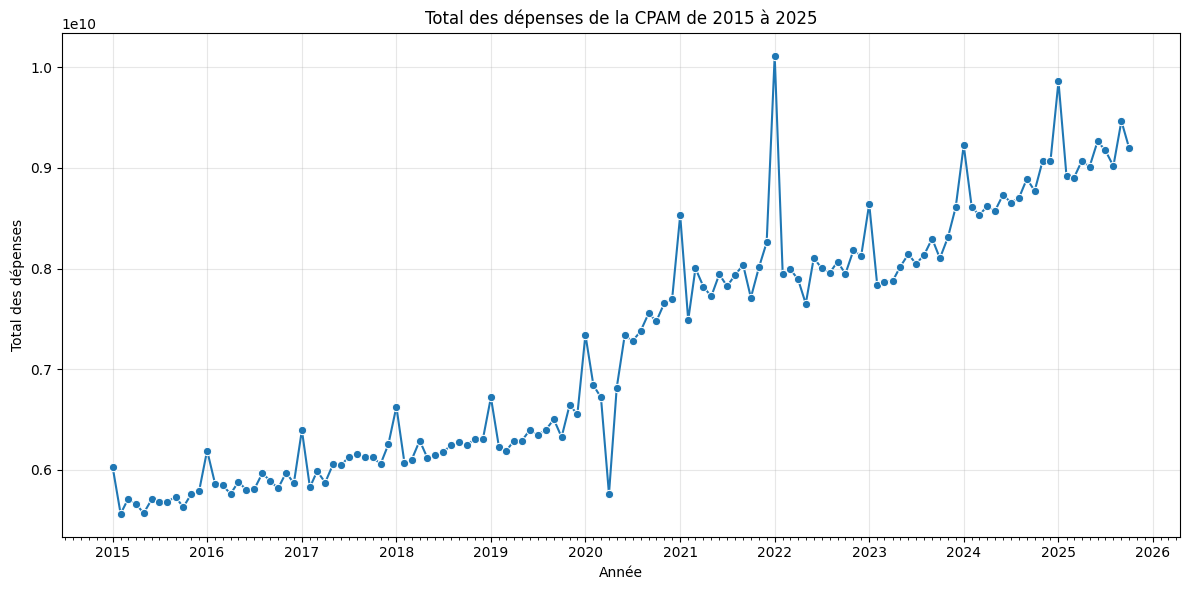

In [15]:
import matplotlib.dates as mdates

def plot_total_depenses(df: pd.DataFrame) -> None:
    """
    Plot des dépenses mensuelles avec affichage des années en abscisse.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=df, x="date", y="Total", marker="o", ax=ax)

    # Afficher uniquement les années sur l'axe X
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())  # garde la granularité mensuelle

    ax.set_title("Total des dépenses de la CPAM de 2015 à 2025")
    ax.set_xlabel("Année")
    ax.set_ylabel("Total des dépenses")
    ax.grid(True, which="major", alpha=0.3)

    fig.tight_layout()
    plt.show()

plot_total_depenses(df)

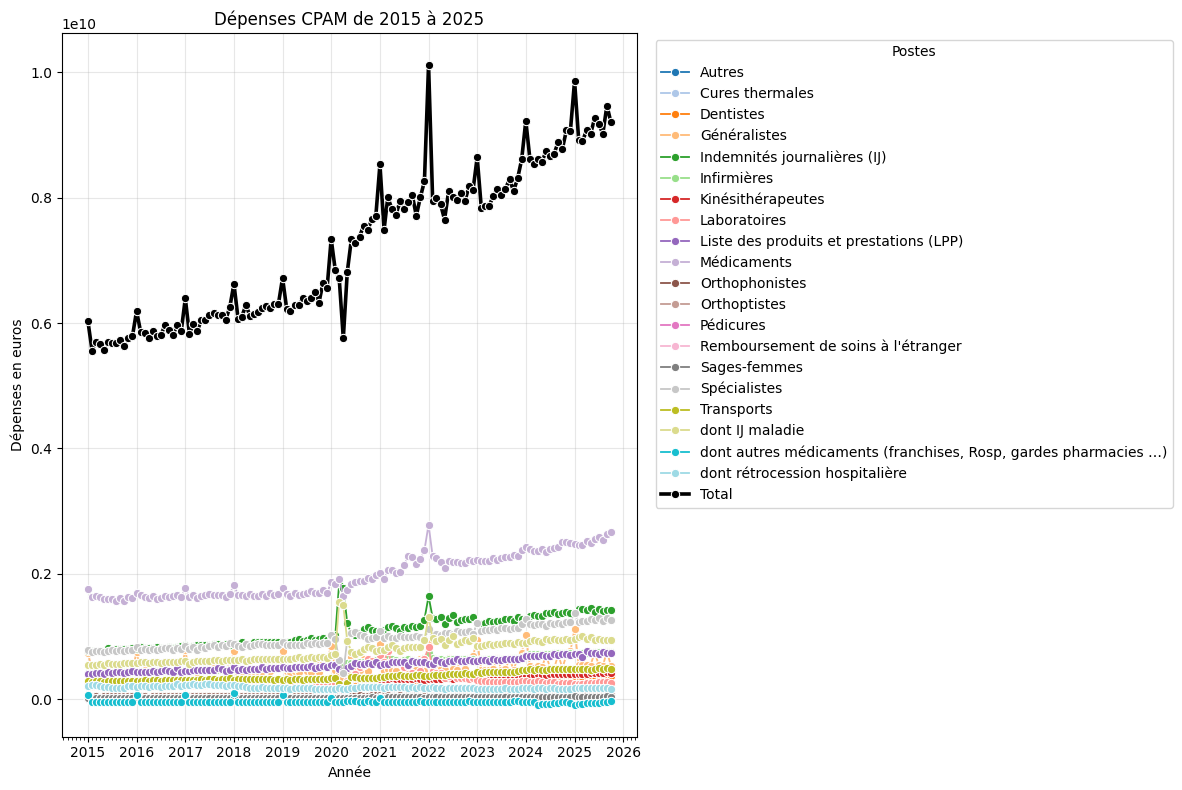

In [34]:
def plot_total_depenses_segmented(df: pd.DataFrame, isUnion: bool = False) -> None:
    """Trace les dépenses mensuelles par poste.

    Le tracé utilise les colonnes globales définies en amont:
    - `df_union_cols_keep` si `isUnion` est `False`
    - `df_cols_keep` si `isUnion` est `True`

    Args:
        df: DataFrame source contenant au minimum une colonne `date` et les
            colonnes de dépenses à tracer.
        isUnion: Indique quelle liste globale de colonnes utiliser.
            `False` (par défaut) utilise `df_union_cols_keep`.
            `True` utilise `df_cols_keep`.

    Returns:
        None. La fonction affiche un graphique Matplotlib.

    Raises:
        KeyError: Si la colonne `date` est absente du DataFrame.
        ValueError: Si aucune colonne à tracer n'est trouvée dans `df`.
    """
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.sort_values("date")

    cols_to_plot = df_union_cols_keep if not isUnion else df_cols_keep
    cols_to_plot = [c for c in cols_to_plot if c in d.columns]

    if not cols_to_plot:
        raise ValueError("Aucune colonne à tracer trouvée dans le DataFrame.")

    fig, ax = plt.subplots(figsize=(12, 8))

    cols_no_total = [c for c in cols_to_plot if c != "Total"]
    palette = sns.color_palette("tab20", n_colors=len(cols_no_total))

    for col, color in zip(cols_no_total, palette):
        sns.lineplot(
            data=d, x="date", y=col, marker="o", linewidth=1.3, ax=ax, label=col, color=color
        )

    if "Total" in cols_to_plot:
        sns.lineplot(
            data=d, x="date", y="Total", marker="o", linewidth=2.6, ax=ax, label="Total", color="black"
        )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.set_title("Dépenses CPAM de 2015 à 2025")
    ax.set_xlabel("Année")
    ax.set_ylabel("Dépenses en euros")
    ax.grid(True, which="major", alpha=0.3)
    ax.legend(title="Postes", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.tight_layout()
    plt.show()
    
plot_total_depenses_segmented(df, isUnion=False)

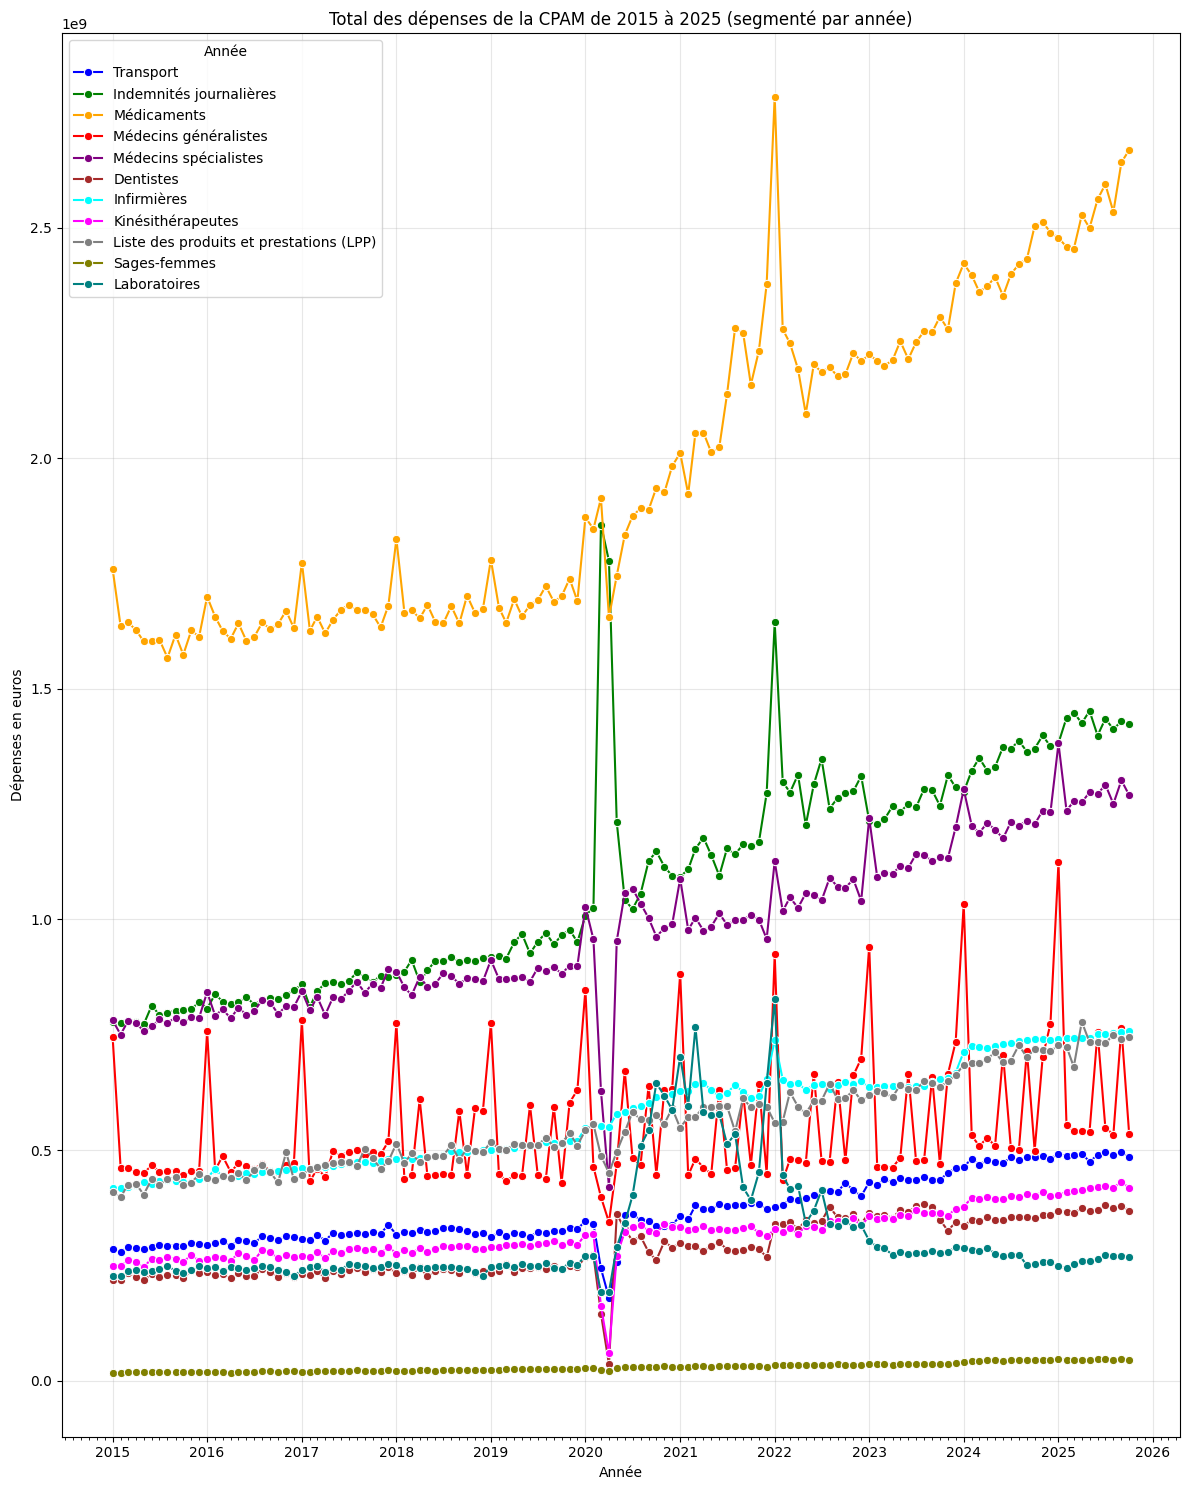

In [ ]:
def plot_depenses_segmented(df: pd.DataFrame) -> None:
    """
    Plot des dépenses mensuelles par poste, avec légende triée par moyenne.
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date")
$
    # Trier les postes par moyenne décroissante
    mean_by_poste = df[postes].mean().sort_values(ascending=False)
    postes_tries = mean_by_poste.index.tolist()

    # Passer en format long pour un seul lineplot (plus propre)
    df_long = df.melt(
        id_vars="date",
        value_vars=postes_tries,
        var_name="cols",
        value_name="Depenses"
    )

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(
        data=df_long,
        x="date",
        y="Depenses",
        hue="Poste",
        hue_order=postes_tries,  # ordre de légende
        marker="o",
        linewidth=1.5,
        ax=ax
    )

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    ax.set_title("Dépenses CPAM (2015-2025) par poste")
    ax.set_xlabel("Année")
    ax.set_ylabel("Dépenses en euros")
    ax.grid(True, which="major", alpha=0.3)

    # Ajouter la moyenne dans chaque label de légende
    handles, labels = ax.get_legend_handles_labels()
    labels_with_mean = [f"{lab} (moy={mean_by_poste[lab]:,.0f})" for lab in labels]
    ax.legend(handles, labels_with_mean, title="Poste (trié par moyenne)")

    fig.tight_layout()
    plt.show()

plot_depenses_segmented(df)
